In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
live_a = pd.read_csv("../samples/mega/live_metrics.csv",)
verbose_a = pd.read_csv("../samples/mega/verbose_statements.csv",)
initial_a = pd.read_csv("../samples/mega/initial_statement.csv",)
live_avg_a = pd.read_csv("../samples/mega_processed/live_avg.csv")
live_avg_norm_a = pd.read_csv("../samples/mega_processed/live_avg_norm.csv")
live_avg_scaled_a = pd.read_csv("../samples/mega_processed/live_avg_scaled.csv")

live_v = pd.read_csv("../samples/ollama/live_metrics.csv",)
verbose_v = pd.read_csv("../samples/ollama/verbose_statements.csv",)
initial_v = pd.read_csv("../samples/ollama/initial_statement.csv",)
live_avg_v = pd.read_csv("../samples/ollama_processed/live_avg.csv")
live_avg_norm_v = pd.read_csv("../samples/ollama_processed/live_avg_norm.csv")
live_avg_scaled_v = pd.read_csv("../samples/ollama_processed/live_avg_scaled.csv")

In [10]:
live_a

,Prompt,GPU Util,Power Draw,GPU Temp,GPU Clock,Mem Clock,Mem Used,Mem Util,Time,Time Delta,Iter
0,Prompt 0,0.00,39.09,28.0,1.080000e+09,1.215000e+09,4.194304e+06,0.00,-2208942136000000000,1.0,1.0
1,Prompt 0,0.00,39.09,28.0,1.080000e+09,1.215000e+09,4.194304e+06,0.00,-2208942135000000000,2.0,2.0
2,Prompt 0,0.00,39.09,28.0,1.080000e+09,1.215000e+09,4.194304e+06,0.00,-2208942135000000000,2.0,3.0
3,Prompt 0,0.00,39.09,28.0,1.080000e+09,1.215000e+09,4.194304e+06,0.00,-2208942134000000000,3.0,4.0
4,Prompt 0,0.00,39.09,28.0,1.080000e+09,1.215000e+09,4.194304e+06,0.00,-2208942134000000000,3.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...
3193,Prompt 407,0.74,244.99,62.0,1.395000e+09,1.215000e+09,6.810501e+09,0.39,-2208940526000000000,1611.0,1.0
3194,Prompt 407,0.74,244.99,62.0,1.395000e+09,1.215000e+09,6.810501e+09,0.39,-2208940525000000000,1612.0,2.0
3195,Prompt 407,0.74,244.99,62.0,1.395000e+09,1.215000e+09,6.810501e+09,0.39,-2208940524000000000,1612.0,3.0
3196,Prompt 407,0.74,244.99,62.0,1.395000e+09,1.215000e+09,6.810501e+09,0.39,-2208940524000000000,1613.0,4.0


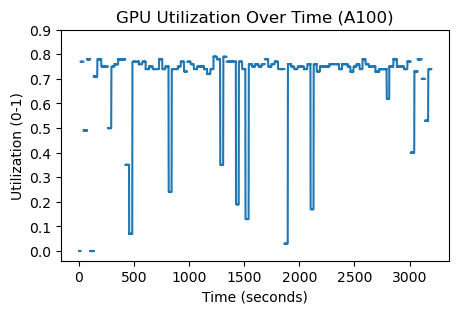

In [ ]:
import matplotlib.pyplot as plt

def plot_series_a(metric, title, xlabel, ylabel, y_ticks, y_ticks_range):
    plt.figure(figsize=(5,3))
    plt.plot(live_a[metric])
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    if y_ticks:
        plt.yticks(y_ticks_range)
    plt.title(title)
    plt.show()

yticks_range = np.arange(0, 1, .10)
plot_series_a("GPU Util", 'GPU Utilization Over Time (A100)',  'Time (seconds)', "Utilization (0-1)", "crazy", yticks_range)

In [24]:
live_a

,Prompt,GPU Util,Power Draw,GPU Temp,GPU Clock,Mem Clock,Mem Used,Mem Util,Time,Time Delta,Iter
0,Prompt 0,0.00,39.09,28.0,1.080000e+09,1.215000e+09,4.194304e+06,0.00,-2208942136000000000,1.0,1.0
1,Prompt 0,0.00,39.09,28.0,1.080000e+09,1.215000e+09,4.194304e+06,0.00,-2208942135000000000,2.0,2.0
2,Prompt 0,0.00,39.09,28.0,1.080000e+09,1.215000e+09,4.194304e+06,0.00,-2208942135000000000,2.0,3.0
3,Prompt 0,0.00,39.09,28.0,1.080000e+09,1.215000e+09,4.194304e+06,0.00,-2208942134000000000,3.0,4.0
4,Prompt 0,0.00,39.09,28.0,1.080000e+09,1.215000e+09,4.194304e+06,0.00,-2208942134000000000,3.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...
3193,Prompt 407,0.74,244.99,62.0,1.395000e+09,1.215000e+09,6.810501e+09,0.39,-2208940526000000000,1611.0,1.0
3194,Prompt 407,0.74,244.99,62.0,1.395000e+09,1.215000e+09,6.810501e+09,0.39,-2208940525000000000,1612.0,2.0
3195,Prompt 407,0.74,244.99,62.0,1.395000e+09,1.215000e+09,6.810501e+09,0.39,-2208940524000000000,1612.0,3.0
3196,Prompt 407,0.74,244.99,62.0,1.395000e+09,1.215000e+09,6.810501e+09,0.39,-2208940524000000000,1613.0,4.0


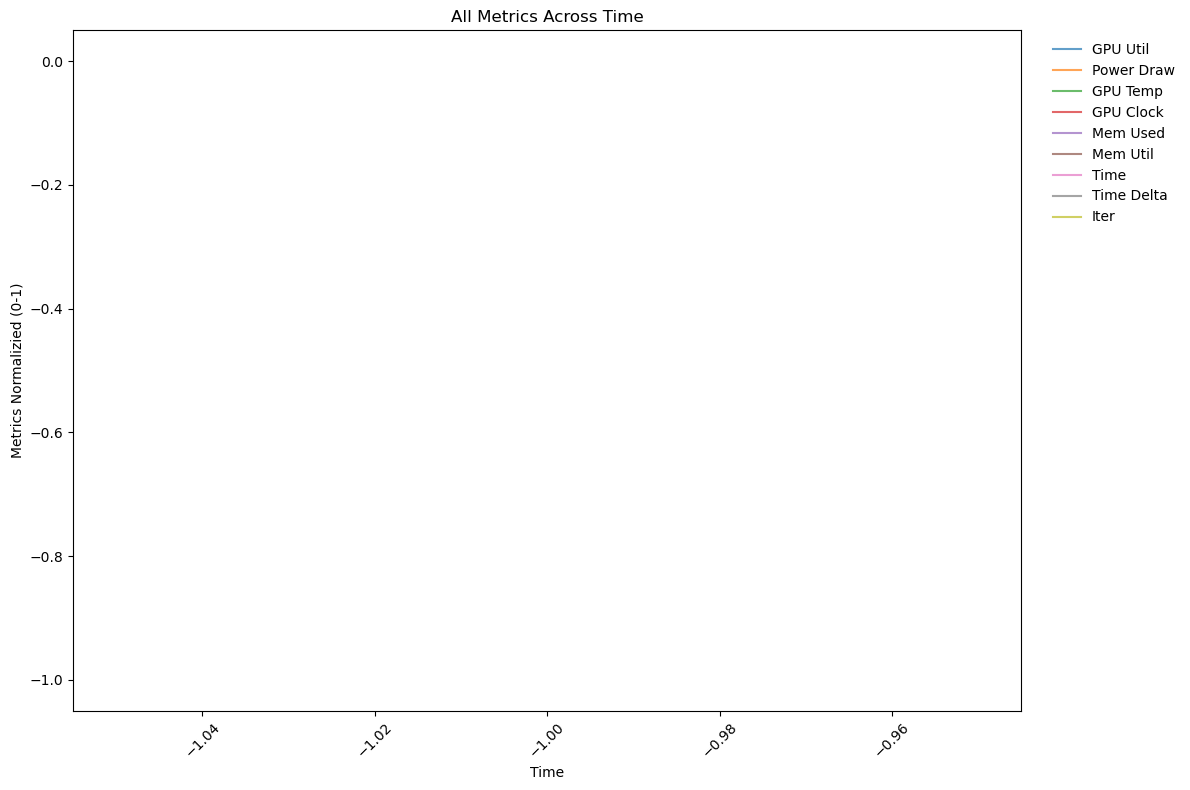

In [25]:
plt.figure(figsize=(12,8))
for col in live_avg_norm_a.columns:
    plt.plot(live_avg_norm_a["Time"], live_avg_norm_a[col], alpha=0.7, label=col)

plt.title("All Metrics Across Time")
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.ylabel("Metrics Normalizied (0-1)")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)
plt.tight_layout()

plt.show()

In [76]:
import warnings
warnings.filterwarnings("ignore")

In [78]:
import pandas as pd
live_avg = pd.read_csv("../samples/mega_processed/live_avg.csv")

In [81]:
y = live['response_time']

to_drop = ['gpu_temp','gpu_curr_clock', 'curr_time','time_delta', 'Iteration', \
                       'memory_clock_util', 'eval_rate', 'response_time', 'curr_memory',]

X = live.drop(columns=to_drop)

In [82]:
import statsmodels.api as sm
from sklearn.preprocessing import Normalizer

model = sm.OLS(y, X,)
res = model.fit()
print(res.summary())

                                 OLS Regression Results                                
Dep. Variable:          response_time   R-squared (uncentered):                   0.732
Model:                            OLS   Adj. R-squared (uncentered):              0.729
Method:                 Least Squares   F-statistic:                              275.4
Date:                Tue, 05 Aug 2025   Prob (F-statistic):                   7.80e-114
Time:                        10:33:35   Log-Likelihood:                         -901.64
No. Observations:                 407   AIC:                                      1811.
Df Residuals:                     403   BIC:                                      1827.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

In [83]:
live_metrics['GPU Clock Utilization'] = live_metrics['GPU Current Clock (MHz)']/intial_statment['GPU Clock Limit (MHz)'][0]
live_metrics['Memory Clock Utilization'] = live_metrics['Memory Current Clock (MHz)']/intial_statment['Memory Clock Limit (MHz)'][0]

In [84]:
intial_statment.to_csv("../samples/mega/initial_statement.csv")
live_metrics.to_csv("../samples/mega/live_metrics.csv")
verbose_statements.to_csv("../samples/mega/verbose_statements.csv")